In [2]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [3]:
import sys

print(sys.executable)

c:\Users\anike\anaconda3\envs\ds_project\python.exe


In [4]:
from src.data.load_data import load_csv
from src.data.preprocess import (
    split_data,
    scale_amount,
    apply_smote,
)

from src.models.train_logistic import train_logistic
from src.models.train_random_forest import train_random_forest
from src.models.train_xgboost import train_xgboost

from src.evaluation.metrics import evaluate_model
from src.evaluation.comparison import compare_models
from src.evaluation.threshold import find_best_threshold

In [ ]:
df = load_csv("../../data/raw/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
X_train, X_test, y_train, y_test = split_data(df)

In [7]:
X_train, X_test, scaler = scale_amount(
    X_train,
    X_test,
)

In [8]:
X_train_smote, y_train_smote = apply_smote(
    X_train,
    y_train,
)

In [9]:
lr = train_logistic(
    X_train,
    y_train,
)

balanced_lr = train_logistic(
    X_train,
    y_train,
    class_weight="balanced",
)

smote_lr = train_logistic(
    X_train_smote,
    y_train_smote,
)

rf = train_random_forest(
    X_train,
    y_train,
    n_estimators=200,
)

best_rf = train_random_forest(
    X_train,
    y_train,
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
)



In [10]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
best_xgb = train_xgboost(
    X_train,
    y_train,
    n_estimators=300,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
)

In [11]:
comparison = compare_models(
    {
        "Logistic": lr,
        "Balanced LR": balanced_lr,
        "SMOTE LR": smote_lr,
        "Random Forest": rf,
        "Tuned RF": best_rf,
        "XGBoost": best_xgb,
    },
    X_test,
    y_test,
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic,0.999175,0.831169,0.653061,0.731429,0.953726
1,Balanced LR,0.975212,0.060241,0.918367,0.113065,0.971558
2,SMOTE LR,0.989712,0.132530,0.897959,0.230971,0.977393
3,Random Forest,0.999614,0.941860,0.826531,0.880435,0.962349
4,Tuned RF,0.999614,0.941860,0.826531,0.880435,0.965063
5,XGBoost,0.999561,0.892473,0.846939,0.869110,0.969412


In [15]:
import sys
print(sys.executable)

c:\Users\anike\anaconda3\envs\ds_project\python.exe


c:\Users\anike\anaconda3\envs\ds_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


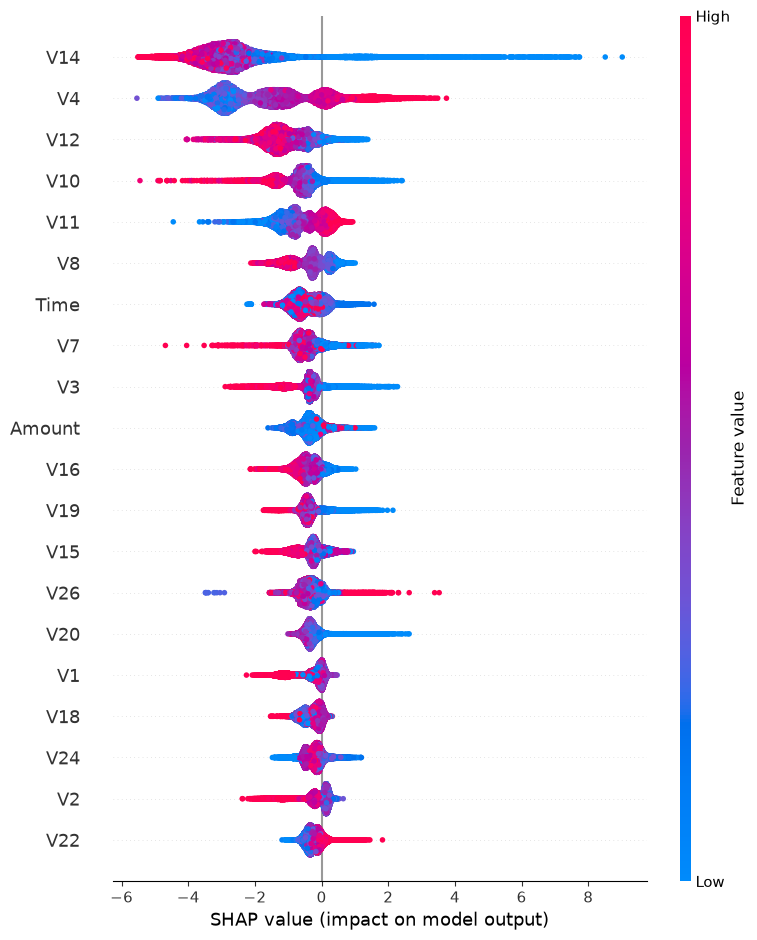

In [18]:
from src.evaluation.shap_analysis import ( create_explainer, summary_plot, bar_plot, waterfall_plot)

explainer = create_explainer(best_xgb)

summary_plot(
    explainer,
    X_test,
)

In [20]:
from src.models.model_utils import save_model, load_model, save_metadata
save_model(
    best_xgb,
    "../../artifacts/xgboost.pkl",
)

save_model(
    scaler,
    "../../artifacts/scaler.pkl",
)

save_metadata(
    {
        "Model": "XGBoost",
        "Precision": comparison.loc[
            comparison["Model"] == "XGBoost",
            "Precision",
        ].iloc[0],
        "Recall": comparison.loc[
            comparison["Model"] == "XGBoost",
            "Recall",
        ].iloc[0],
        "F1": comparison.loc[
            comparison["Model"] == "XGBoost",
            "F1 Score",
        ].iloc[0],
    },
    "../../artifacts/model_metadata.json",
)